## Workflow in this Notebook
1. Data load aur explore
2. Missing values handle karna
3. Categorical features encode karna
4. Train/Test split
5. Decision Tree Classifier train karna
6. Model evaluate karna (accuracy, confusion matrix, classification report)
7. Tree visualize karna
8. Feature importance dekhna
9. Overfitting check (max_depth ke sath compare)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [5]:
df = pd.read_csv(
    "../../employee_data_cleaned.csv"
)

df.head()

,Employee_ID,Name,Gender,Age,Department,City,Experience_Years,Education_Level,Job_Level,Salary,Performance_Score,Joining_Date,Is_Remote,Employment_Type,Monthly_Work_Hours,Projects_Completed,Training_Hours,Satisfaction_Score,Attrition,Email
0,1001,Farhan Ahmed,Male,38.0,Marketing,Karachi,4,Intermediate,Senior,111512.0,7.900000,2014-09-18,True,Full-time,169,150,77,1.1,No,farhan.ahmed1001@company.com
1,1002,Farhan Chaudhry,Female,35.0,Design,Rawalpindi,8,Intermediate,Senior,111512.0,6.700000,2017-06-27,True,Part-time,183,7,11,2.5,No,farhan.chaudhry1002@company.com
2,1003,Hira Sheikh,Female,23.0,Design,Lahore,3,MPhil,Junior,56050.0,7.443687,2015-07-24,True,Full-time,177,6,29,4.5,No,hira.sheikh1003@company.com
3,1004,Saad Butt,Female,42.0,Support,Islamabad,6,Master,Senior,118533.0,7.443687,2017-11-02,True,Full-time,188,18,71,1.9,No,unknown@company.com
4,1005,Shahzaib Qureshi,Male,35.0,IT,Peshawar,10,MPhil,Junior,77905.0,9.300000,2021-01-21,True,Full-time,190,30,18,NaN,No,shahzaib.qureshi1005@company.com


In [6]:
df.shape

(500, 20)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Employee_ID         500 non-null    int64  
 1   Name                500 non-null    str    
 2   Gender              500 non-null    str    
 3   Age                 500 non-null    float64
 4   Department          500 non-null    str    
 5   City                500 non-null    str    
 6   Experience_Years    500 non-null    int64  
 7   Education_Level     500 non-null    str    
 8   Job_Level           500 non-null    str    
 9   Salary              500 non-null    float64
 10  Performance_Score   500 non-null    float64
 11  Joining_Date        488 non-null    str    
 12  Is_Remote           500 non-null    bool   
 13  Employment_Type     500 non-null    str    
 14  Monthly_Work_Hours  500 non-null    int64  
 15  Projects_Completed  500 non-null    int64  
 16  Training_Hours     

In [8]:
df.isnull().sum()

Employee_ID            0
Name                   0
Gender                 0
Age                    0
Department             0
City                   0
Experience_Years       0
Education_Level        0
Job_Level              0
Salary                 0
Performance_Score      0
Joining_Date          12
Is_Remote              0
Employment_Type        0
Monthly_Work_Hours     0
Projects_Completed     0
Training_Hours         0
Satisfaction_Score    18
Attrition              0
Email                  0
dtype: int64

In [9]:
df['Attrition'].value_counts()

Attrition
No     405
Yes     95
Name: count, dtype: int64

In [10]:
df = df.drop(columns=['Employee_ID', 'Name', 'Email', 'Joining_Date'])
df.head()

,Gender,Age,Department,City,Experience_Years,Education_Level,Job_Level,Salary,Performance_Score,Is_Remote,Employment_Type,Monthly_Work_Hours,Projects_Completed,Training_Hours,Satisfaction_Score,Attrition
0,Male,38.0,Marketing,Karachi,4,Intermediate,Senior,111512.0,7.900000,True,Full-time,169,150,77,1.1,No
1,Female,35.0,Design,Rawalpindi,8,Intermediate,Senior,111512.0,6.700000,True,Part-time,183,7,11,2.5,No
2,Female,23.0,Design,Lahore,3,MPhil,Junior,56050.0,7.443687,True,Full-time,177,6,29,4.5,No
3,Female,42.0,Support,Islamabad,6,Master,Senior,118533.0,7.443687,True,Full-time,188,18,71,1.9,No
4,Male,35.0,IT,Peshawar,10,MPhil,Junior,77905.0,9.300000,True,Full-time,190,30,18,NaN,No


In [11]:
df['Satisfaction_Score'] = df['Satisfaction_Score'].fillna(df['Satisfaction_Score'].median())
df.isnull().sum()

Gender                0
Age                   0
Department            0
City                  0
Experience_Years      0
Education_Level       0
Job_Level             0
Salary                0
Performance_Score     0
Is_Remote             0
Employment_Type       0
Monthly_Work_Hours    0
Projects_Completed    0
Training_Hours        0
Satisfaction_Score    0
Attrition             0
dtype: int64

In [12]:
df['Satisfaction_Score'] = df['Satisfaction_Score'].fillna(df['Satisfaction_Score'].median())
df.isnull().sum()

Gender                0
Age                   0
Department            0
City                  0
Experience_Years      0
Education_Level       0
Job_Level             0
Salary                0
Performance_Score     0
Is_Remote             0
Employment_Type       0
Monthly_Work_Hours    0
Projects_Completed    0
Training_Hours        0
Satisfaction_Score    0
Attrition             0
dtype: int64

In [14]:
categorical_cols = df.select_dtypes(include='object').columns.tolist()
categorical_cols

C:\Users\Milon\AppData\Local\Temp\ipykernel_20704\2011215904.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include='object').columns.tolist()


['Gender',
 'Department',
 'City',
 'Education_Level',
 'Job_Level',
 'Employment_Type',
 'Attrition']

In [15]:
le = LabelEncoder()
df_encoded = df.copy()

for col in categorical_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col])

df_encoded.head()

,Gender,Age,Department,City,Experience_Years,Education_Level,Job_Level,Salary,Performance_Score,Is_Remote,Employment_Type,Monthly_Work_Hours,Projects_Completed,Training_Hours,Satisfaction_Score,Attrition
0,1,38.0,4,2,4,1,4,111512.0,7.900000,True,1,169,150,77,1.1,0
1,0,35.0,0,6,8,1,4,111512.0,6.700000,True,2,183,7,11,2.5,0
2,0,23.0,0,3,3,2,0,56050.0,7.443687,True,1,177,6,29,4.5,0
3,0,42.0,7,1,6,3,4,118533.0,7.443687,True,1,188,18,71,1.9,0
4,1,35.0,3,5,10,2,0,77905.0,9.300000,True,1,190,30,18,3.1,0


In [16]:
X = df_encoded.drop(columns=['Attrition'])
y = df_encoded['Attrition']

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)


Training size: (400, 15)
Testing size: (100, 15)


In [18]:
dt_model = DecisionTreeClassifier(
    criterion='gini',
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42
)

dt_model.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: dict, list of dict or ""balanced"", default=NoneWeights associated with classes in the form ``{class_label: weight}``.If None, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are co

In [19]:
y_pred = dt_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.49


In [20]:
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print()
print("Classification Report:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[38 43]
 [ 8 11]]

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.47      0.60        81
           1       0.20      0.58      0.30        19

    accuracy                           0.49       100
   macro avg       0.51      0.52      0.45       100
weighted avg       0.71      0.49      0.54       100



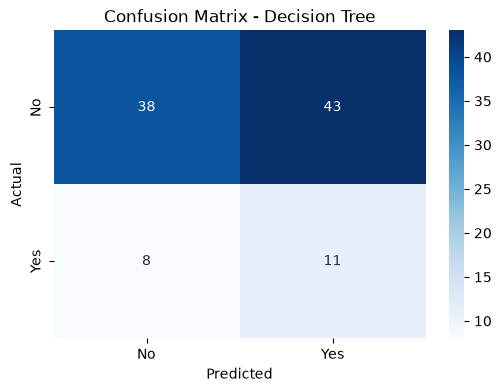

In [21]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No','Yes'], yticklabels=['No','Yes'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Decision Tree')
plt.show()

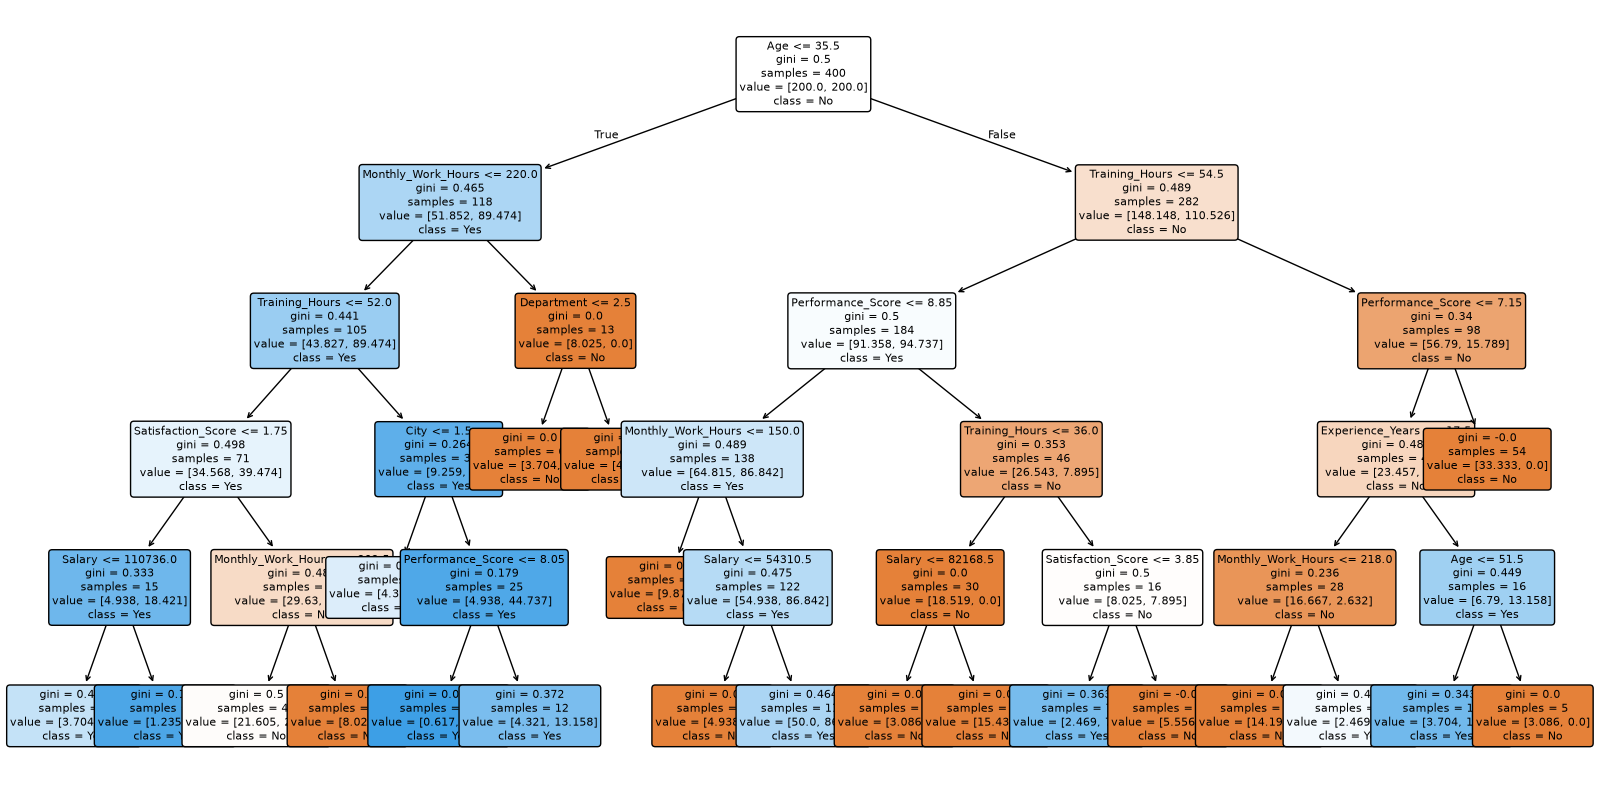

In [29]:
plt.figure(figsize=(20,10))
plot_tree(dt_model, feature_names=X.columns, class_names=['No','Yes'],
          filled=True, rounded=True, fontsize=8)
plt.show()

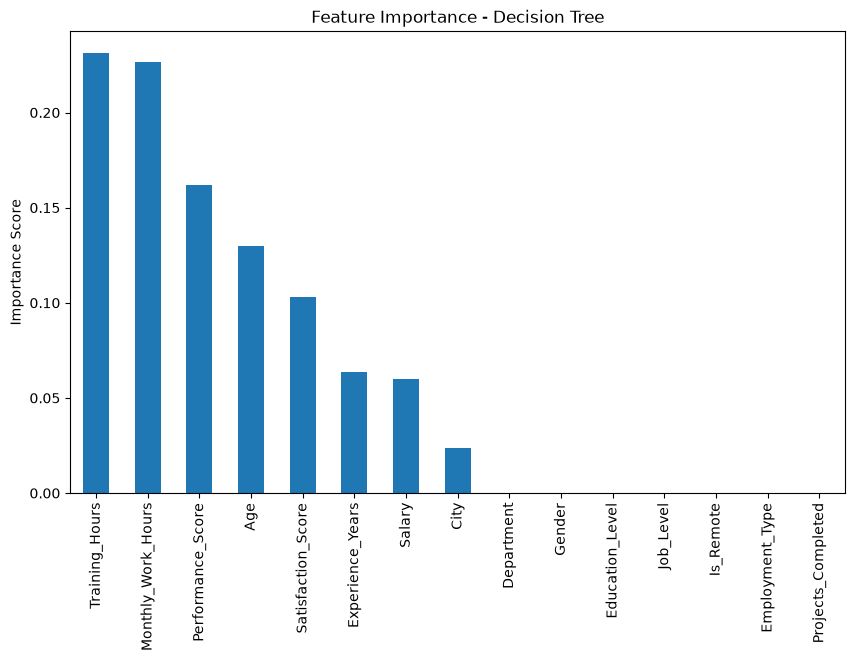

In [30]:
importance = pd.Series(dt_model.feature_importances_, index=X.columns)
importance = importance.sort_values(ascending=False)

plt.figure(figsize=(10,6))
importance.plot(kind='bar')
plt.title('Feature Importance - Decision Tree')
plt.ylabel('Importance Score')
plt.show()

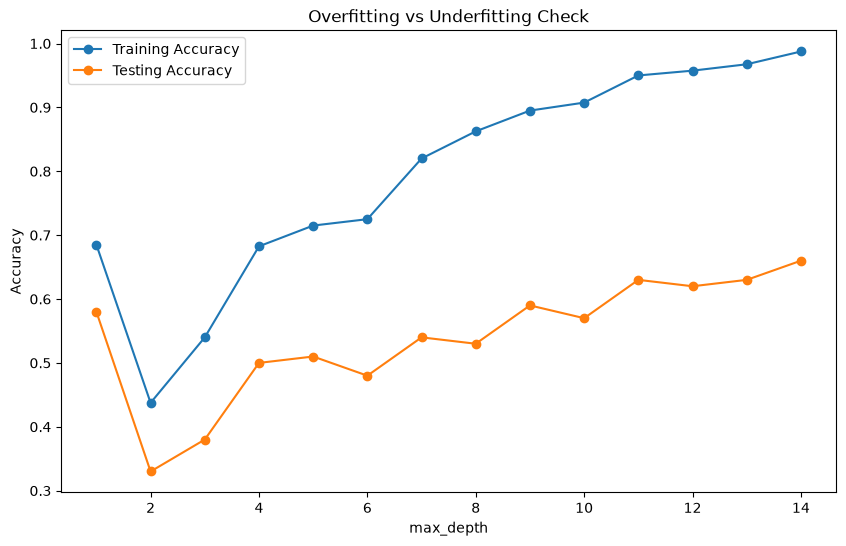

In [31]:
depths = range(1, 15)
train_scores = []
test_scores = []

for d in depths:
    model = DecisionTreeClassifier(max_depth=d, random_state=42, class_weight='balanced')
    model.fit(X_train, y_train)
    train_scores.append(accuracy_score(y_train, model.predict(X_train)))
    test_scores.append(accuracy_score(y_test, model.predict(X_test)))

plt.figure(figsize=(10,6))
plt.plot(depths, train_scores, label='Training Accuracy', marker='o')
plt.plot(depths, test_scores, label='Testing Accuracy', marker='o')
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.title('Overfitting vs Underfitting Check')
plt.legend()
plt.show()